# BLIP 이미지 캡셔닝: 이미지에서 문장 생성하기

**이미지 캡셔닝**은 사진을 보고 `강아지가 잔디 위에 앉아 있다`와 같은 설명 문장을 만드는 작업이다. 정해진 이름 중 하나를 고르는 이미지 분류와 달리, 사진의 내용을 문장으로 직접 표현한다.

**BLIP(블립)**은 이미지를 이해하고 그 내용을 글로 표현하도록 미리 학습된 모델이다. 이번 실습에서는 사진 한 장이 `이미지 → 이미지 특징 → 단어 token 생성 → 완성 문장`으로 바뀌는 과정을 확인한다.

## BLIP
BLIP (Bootstrapping Language-Image Pre-training)은 Salesforce에서 2022년에 발표한 멀티모달(Vision-Language) AI 모델이다.

BLIP은 이미지와 문장이 서로 잘 맞는지 배우고, 이미지를 보고 문장을 만드는 방법도 함께 배운다. 이를 위해 같은 모델 안에서 이미지와 글을 따로 읽거나, 두 정보를 합치거나, 다음 단어를 생성한다.

이번 이미지 캡셔닝 실습에서 중요한 부분은 **이미지 특징을 참고하여 다음 token을 하나씩 만드는 과정**이다. 이미지 특징은 색·모양·물체·위치처럼 문장을 만드는 데 필요한 정보를 숫자로 표현한 값이다. token은 모델이 문장을 처리할 때 사용하는 단어나 단어 조각이다.

### 구조 그림에 나오는 참고 용어

이번 캡셔닝 실습에서 꼭 볼 용어는 문장을 만드는 **LM**이다. 나머지는 BLIP이 함께 학습한 기능을 구분하기 위한 참고 용어이므로 지금 모두 외울 필요는 없다.

- **MED**: 이미지 이해, 이미지-문장 비교, 문장 생성을 한 구조에서 처리하는 BLIP의 기본 설계이다.
- **ITC**: 서로 맞는 이미지와 문장의 특징을 가깝게 만드는 학습이다.
- **ITM**: 주어진 이미지와 문장이 실제 짝인지 맞히는 학습이다.
- **LM**: 이미지와 앞에서 만든 token을 보고 다음 token을 예측하는 학습이다.
- **CapFilt**: 웹에서 모은 부정확한 설명을 새로 만들거나 걸러 학습 데이터를 정리하는 방법이다.

### BLIP 이미지 캡셔닝 구조 그림 해석

![BLIP MED 구조](https://arxiv.org/html/2201.12086v2/MED.png)

이 그림은 BLIP이 하나의 이미지를 세 가지 방식으로 학습하는 모습을 보여 준다.

1. **ITC(Image-Text Contrastive Learning)**: 서로 맞는 이미지와 문장을 가까운 특징으로 만든다.
2. **ITM(Image-Text Matching)**: 이미지와 문장이 올바른 짝인지 판단한다.
3. **LM(Language Modeling)**: 이미지 특징을 보면서 `a → woman → sitting → ...`처럼 문장을 한 조각씩 만든다.

이번 코드에서 직접 사용하는 부분은 오른쪽 **LM 경로**이다. `a picture of`는 모델에게 먼저 건네는 시작 문구이며, 모델은 이미지 특징을 참고해 그 뒤에 올 내용을 생성한다.

```text
이미지 → 이미지 특징 추출 → 단어 token 생성 → 문장 완성
```

> **핵심**: 이미지에서 특징을 뽑은 뒤, 그 특징에 어울리는 단어를 차례대로 이어 문장을 만든다.

출처: Li et al., *BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation* (2022), Figure 2, [arXiv:2201.12086v2](https://arxiv.org/html/2201.12086v2#S2.F2), CC BY 4.0.

## 여러 문장 후보 중 하나 선택하기

모델은 다음에 올 단어를 하나만 바로 확정하지 않고 여러 후보에 점수를 매긴다. **Beam search**는 점수가 높은 문장 후보를 몇 개 남겨 끝까지 비교하는 방법이다. 예를 들어 `강아지가 앉아 있다`와 `강아지가 달리고 있다`를 함께 만들어 본 뒤 전체 점수가 더 높은 문장을 고른다.

문장이 끝났다는 **EOS** 신호가 나오면 생성을 멈춘다. EOS가 늦게 나오더라도 문장이 끝없이 길어지지 않도록 `max_new_tokens`로 최대 생성 길이를 정한다.

아래 코드는 세 개의 완성된 후보 중 점수가 가장 높은 문장을 고르고 EOS를 제거한다. 실제 BLIP 결과가 아니라, 후보 선택과 종료 신호의 역할만 빠르게 확인하는 예제이다.

In [1]:
MAX_NEW_TOKENS = 30

beam_candidates = [
    {"tokens": ["a", "dog", "sitting", "on", "a", "beach", "<eos>"], "score": -1.4},
    {"tokens": ["a", "golden", "retriever", "outdoors", "<eos>"], "score": -1.8},
    {"tokens": ["a", "dog", "running", "near", "water", "<eos>"], "score": -2.1},
]
best_candidate = max(beam_candidates, key=lambda candidate: candidate["score"])
decoded_tokens = [token for token in best_candidate["tokens"] if token != "<eos>"]

print("선택된 후보:", " ".join(decoded_tokens))
print("EOS 제외 token 수:", len(decoded_tokens))
print("생성 상한 이내:", len(decoded_tokens) <= MAX_NEW_TOKENS)

선택된 후보: a dog sitting on a beach
EOS 제외 token 수: 6
생성 상한 이내: True


## 데모 이미지를 RGB 입력으로 준비하기

다음 셀은 URL에서 데모 이미지를 내려받아 모델이 읽을 수 있는 RGB 형식으로 바꾼다. 화면에 사진이 표시되면 만들어진 `image`를 다음 셀의 모델 입력으로 사용한다.

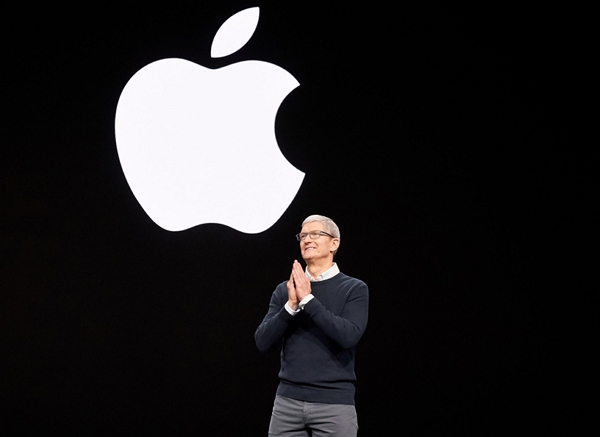

In [7]:
from io import BytesIO

import requests
from IPython.display import display
from PIL import Image

# DEMO_IMAGE_URL = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"
DEMO_IMAGE_URL = "https://cdn.digitaltoday.co.kr/news/photo/202604/658197_607672_4059.jpg"

response = requests.get(DEMO_IMAGE_URL, timeout=30)
response.raise_for_status()
image = Image.open(BytesIO(response.content)).convert("RGB")
display(image)

## 이미지를 모델 입력으로 바꾸고 문장 생성하기

모델은 사진 파일과 글자를 그대로 읽지 못하므로 `BlipProcessor`가 숫자 Tensor로 바꾼다.

`images=image`에는 앞 셀에서 준비한 사진을 넣고, `text=prompt`에는 문장의 시작 문구를 넣는다. 이미지는 `pixel_values`가 되고, 시작 문구는 `input_ids`와 `attention_mask`가 된다. 이 값들은 모델과 같은 CPU 또는 GPU로 이동한다.

`a picture of`는 `~의 사진`이라는 뜻의 **prompt(시작 문구)**이다. 모델은 이 문구 다음에 이미지 설명을 이어 쓰므로, 결과는 `a picture of a dog ...`처럼 시작할 수 있다. prompt를 빼면 모델이 첫 단어부터 스스로 생성한다.

`generate()`는 이미지 특징을 참고해 token을 만들고, `decode()`는 token 번호를 사람이 읽는 문장으로 되돌린다. `num_beams=3`은 문장 후보 3개를 비교한다는 뜻이고, `max_new_tokens=30`은 새로 만들 token을 최대 30개로 제한한다.

실행 결과에서는 입력 세 종류의 shape와 최종 `caption`을 확인한다.

In [3]:
import torch
from transformers import BlipForConditionalGeneration, BlipProcessor

MODEL_ID = "Salesforce/blip-image-captioning-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = BlipProcessor.from_pretrained(MODEL_ID)
model = BlipForConditionalGeneration.from_pretrained(MODEL_ID).to(device)
model.eval()

prompt = "a picture of"

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

C:\Users\playdata2\miniforge3\envs\llm_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\playdata2\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

### BLIP 입력 변환과 캡션 생성하기

앞 셀에서 모델과 시작 문구까지 준비했다. 다음 코드는 `image`와 `prompt`를 모델 입력으로 바꾸고, 이미지 특징을 참고해 캡션 token을 생성한 뒤 문장으로 되돌린다. 실행 후에는 각 입력의 shape와 최종 `caption`을 확인한다.

In [8]:
# 모델에게 전달할 입력 값
inputs = processor(
    images=image,  # 데모 이미지
    text=prompt,   # 지정된 Prompt 뒤로 문구 생성
    return_tensors="pt", # Python Tensor
).to(device)

max_new_tokens = 30

# autograd 끄기, 기록용 메모리 사용 X -> 메모리 아끼기
with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens, # 답변 최대 토큰 수
        num_beams = 3 # 문장 후보 수
    )

# 모델의 답변(토큰 id 목록)을 사람이 볼 수 있는 text로 변환
caption = processor.decode(
    output_ids[0],
    skip_special_tokens=True
)

print("caption: ", caption)

caption:  a picture of apple ceo tim cook standing in front of an apple logo


## 생성 캡션의 시각적 근거 점검

**Hallucination(환각)** 은 사진에 없는 내용을 모델이 있는 것처럼 말하는 오류이다. <br>
예를 들어 사진에는 강아지만 있는데 `a dog playing with a ball`이라고 생성하면 공에 대한 설명은 환각이다.

문장이 자연스럽다고 해서 반드시 사진과 맞는 것은 아니다. 생성된 문장에서 사람·동물·물건·행동·장소·개수를 하나씩 찾아 실제 사진에 있는지 확인해야 한다. 구체적인 내용을 prompt에 미리 넣으면 모델이 사진보다 prompt를 따라 잘못된 내용을 만들 수도 있다.

문장 후보 수를 늘려도 환각이 자동으로 사라지지는 않는다.

(이 모델의 공식 예시는 영어이므로 한국어 문장 품질은 별도로 확인해야 한다.)
